<a href="https://colab.research.google.com/github/vijayragav2309-eng/MACHINE-LEARNING/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

%matplotlib inline
pd.set_option("display.max_rows", None,"display.max_columns", None)
warnings.simplefilter(action='ignore')
plt.style.use('seaborn-v0_8')

In [10]:
df_main = pd.read_csv('/content/CAR DETAILS FROM CAR DEKHO.csv')

In [11]:
df_main.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [12]:
df_main.shape

(4340, 8)

In [13]:
df_main.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [14]:
df_main.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [15]:
df_main.isna().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [17]:
df_main['Age'] = 2020 - df_main['year']
df_main.drop('year',axis=1,inplace = True)

In [18]:
df_main.rename(columns = {'Selling_Price':'Selling_Price(lacs)','Present_Price':'Present_Price(lacs)','Owner':'Past_Owners'},inplace = True)

In [19]:
df_main.columns

Index(['name', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'Age'],
      dtype='object')

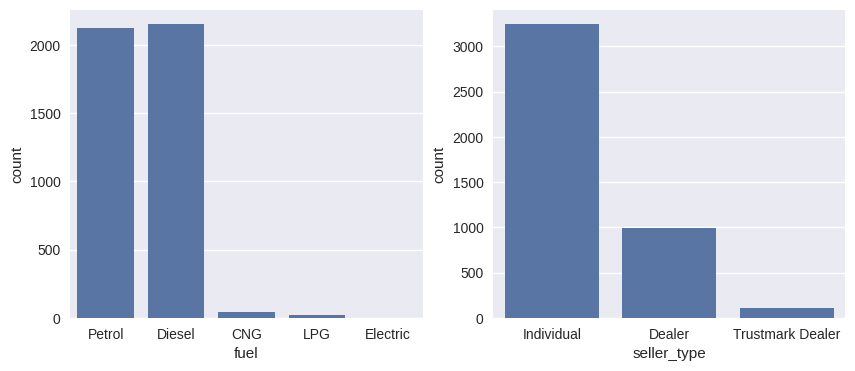

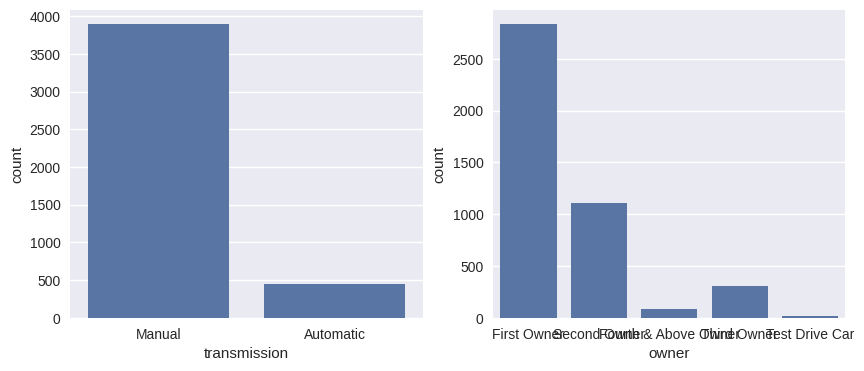

In [21]:
cat_cols = ['fuel','seller_type','transmission','owner']
i=0
while i < 4:
    fig = plt.figure(figsize=[10,4])
    #ax1 = fig.add_subplot(121)
    #ax2 = fig.add_subplot(122)

    #ax1.title.set_text(cat_cols[i])
    plt.subplot(1,2,1)
    sns.countplot(x=cat_cols[i], data=df_main)
    i += 1

    #ax2.title.set_text(cat_cols[i])
    plt.subplot(1,2,2)
    sns.countplot(x=cat_cols[i], data=df_main)
    i += 1

    plt.show()

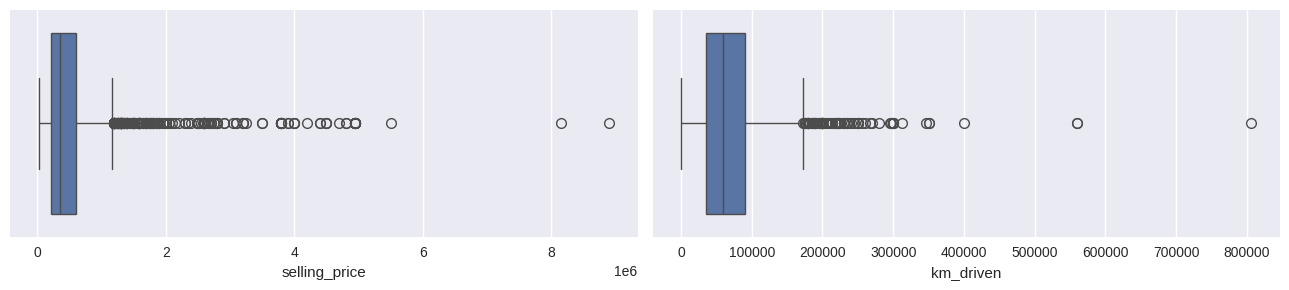

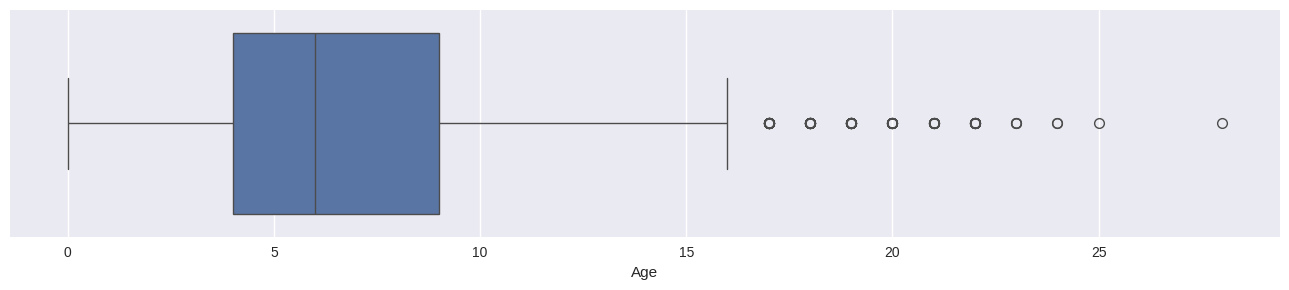

In [23]:
num_cols = ['selling_price', 'km_driven', 'Age']

i = 0
while i < len(num_cols):
    fig = plt.figure(figsize=[13,3])

    # Determine how many plots are needed in this figure
    plots_in_this_figure = min(2, len(num_cols) - i)

    # Plot the first column
    ax1 = fig.add_subplot(1, plots_in_this_figure, 1)
    sns.boxplot(x=num_cols[i], data=df_main, ax=ax1)
    i += 1

    # Plot the second column if available
    if plots_in_this_figure == 2:
        ax2 = fig.add_subplot(1, plots_in_this_figure, 2)
        sns.boxplot(x=num_cols[i], data=df_main, ax=ax2)
        i += 1

    plt.tight_layout()
    plt.show()

In [25]:
df_main[df_main['selling_price'] > df_main['selling_price'].quantile(0.99)]

,name,selling_price,km_driven,fuel,seller_type,transmission,owner,Age
89,Mercedes-Benz S-Class S 350d Connoisseurs Edition,8150000,6500,Diesel,Dealer,Automatic,First Owner,3
101,Mercedes-Benz E-Class Exclusive E 200 BSIV,4500000,9800,Petrol,Dealer,Automatic,First Owner,2
539,Mercedes-Benz GL-Class 350 CDI Blue Efficiency,4400000,100000,Diesel,Individual,Automatic,Second Owner,6
553,Mercedes-Benz C-Class Progressive C 220d,3800000,10000,Diesel,Dealer,Automatic,First Owner,2
555,BMW X5 xDrive 30d xLine,4950000,30000,Diesel,Dealer,Automatic,First Owner,1
572,Mercedes-Benz C-Class Progressive C 220d,3800000,10000,Diesel,Dealer,Automatic,First Owner,2
574,BMW X5 xDrive 30d xLine,4950000,30000,Diesel,Dealer,Automatic,First Owner,1
591,Mercedes-Benz C-Class Progressive C 220d,3800000,10000,Diesel,Dealer,Automatic,First Owner,2
593,BMW X5 xDrive 30d xLine,4950000,30000,Diesel,Dealer,Automatic,First Owner,1
610,Mercedes-Benz C-Class Progressive C 220d,3800000,10000,Diesel,Dealer,Automatic,First Owner,2


In [27]:
df_main[df_main['selling_price'] > df_main['selling_price'].quantile(0.99)]

,name,selling_price,km_driven,fuel,seller_type,transmission,owner,Age
89,Mercedes-Benz S-Class S 350d Connoisseurs Edition,8150000,6500,Diesel,Dealer,Automatic,First Owner,3
101,Mercedes-Benz E-Class Exclusive E 200 BSIV,4500000,9800,Petrol,Dealer,Automatic,First Owner,2
539,Mercedes-Benz GL-Class 350 CDI Blue Efficiency,4400000,100000,Diesel,Individual,Automatic,Second Owner,6
553,Mercedes-Benz C-Class Progressive C 220d,3800000,10000,Diesel,Dealer,Automatic,First Owner,2
555,BMW X5 xDrive 30d xLine,4950000,30000,Diesel,Dealer,Automatic,First Owner,1
572,Mercedes-Benz C-Class Progressive C 220d,3800000,10000,Diesel,Dealer,Automatic,First Owner,2
574,BMW X5 xDrive 30d xLine,4950000,30000,Diesel,Dealer,Automatic,First Owner,1
591,Mercedes-Benz C-Class Progressive C 220d,3800000,10000,Diesel,Dealer,Automatic,First Owner,2
593,BMW X5 xDrive 30d xLine,4950000,30000,Diesel,Dealer,Automatic,First Owner,1
610,Mercedes-Benz C-Class Progressive C 220d,3800000,10000,Diesel,Dealer,Automatic,First Owner,2


In [29]:
df_main[df_main['km_driven'] > df_main['km_driven'].quantile(0.99)]

,name,selling_price,km_driven,fuel,seller_type,transmission,owner,Age
69,Chevrolet Tavera Neo LS B3 - 7(C) seats BSIII,280000,350000,Diesel,Individual,Manual,Second Owner,10
70,Toyota Corolla Altis Diesel D4DG,350000,230000,Diesel,Individual,Manual,First Owner,9
197,Mahindra Xylo E4,229999,230000,Diesel,Individual,Manual,Third Owner,11
525,Maruti SX4 S Cross DDiS 320 Delta,665000,560000,Diesel,Dealer,Manual,First Owner,4
1101,Tata Indica DLS,85000,300000,Diesel,Individual,Manual,Second Owner,14
1116,Toyota Innova 2.5 V Diesel 7-seater,200000,223000,Diesel,Individual,Manual,First Owner,15
1243,Maruti Swift VXI BSIII,250000,806599,Petrol,Dealer,Manual,First Owner,11
1253,Toyota Corolla Altis D-4D J,715000,234000,Diesel,Individual,Manual,First Owner,6
1414,Skoda Superb Elegance 2.0 TDI CR AT,450000,235000,Diesel,Individual,Automatic,First Owner,9
1426,Mahindra Scorpio VLX AT 2WD BSIII,225000,223660,Diesel,Individual,Automatic,Third Owner,16


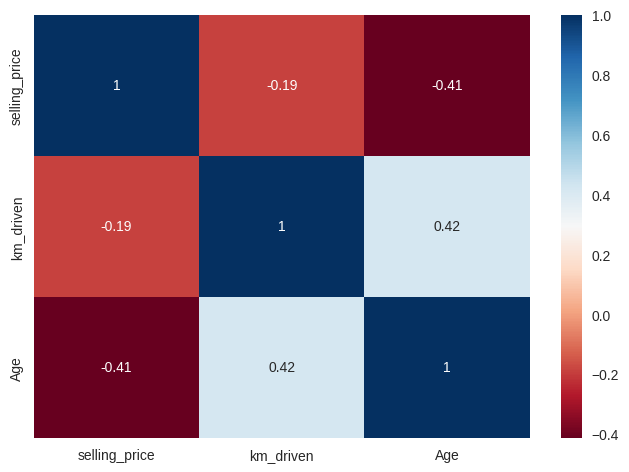

In [31]:
sns.heatmap(df_main.select_dtypes(include=np.number).corr(), annot=True, cmap="RdBu")
plt.show()

In [33]:
df_main.select_dtypes(include=np.number).corr()['selling_price']

,selling_price
selling_price,1.000000
km_driven,-0.192289
Age,-0.413922


In [35]:
df_main.pivot_table(values='selling_price', index='seller_type', columns='fuel')

fuel,CNG,Diesel,Electric,LPG,Petrol
seller_type,,,,,
Dealer,311444.333333,9.423081e+05,310000.0,240000.000000,475017.552863
Individual,267225.741935,5.616871e+05,NaN,164545.409091,297196.682972
Trustmark Dealer,NaN,1.184583e+06,NaN,NaN,675277.777778


In [37]:
df_main.pivot_table(values='selling_price', index='seller_type', columns='transmission')

transmission,Automatic,Manual
seller_type,,
Dealer,1.571880e+06,484419.508366
Individual,1.191722e+06,370861.010224
Trustmark Dealer,1.953158e+06,677289.156627


In [38]:
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

In [39]:
CV = []
R2_train = []
R2_test = []

def car_pred_model(model,model_name):
    # Training model
    model.fit(X_train,y_train)

    # R2 score of train set
    y_pred_train = model.predict(X_train)
    R2_train_model = r2_score(y_train,y_pred_train)
    R2_train.append(round(R2_train_model,2))

    # R2 score of test set
    y_pred_test = model.predict(X_test)
    R2_test_model = r2_score(y_test,y_pred_test)
    R2_test.append(round(R2_test_model,2))

    # R2 mean of train set using Cross validation
    cross_val = cross_val_score(model ,X_train ,y_train ,cv=5)
    cv_mean = cross_val.mean()
    CV.append(round(cv_mean,2))

    # Printing results
    print("Train R2-score :",round(R2_train_model,2))
    print("Test R2-score :",round(R2_test_model,2))
    print("Train CV scores :",cross_val)
    print("Train CV mean :",round(cv_mean,2))

    # Plotting Graphs
    # Residual Plot of train data
    fig, ax = plt.subplots(1,2,figsize = (10,4))
    ax[0].set_title('Residual Plot of Train samples')
    sns.distplot((y_train-y_pred_train),hist = False,ax = ax[0])
    ax[0].set_xlabel('y_train - y_pred_train')

    # Y_test vs Y_train scatter plot
    ax[1].set_title('y_test vs y_pred_test')
    ax[1].scatter(x = y_test, y = y_pred_test)
    ax[1].set_xlabel('y_test')
    ax[1].set_ylabel('y_pred_test')

    plt.show()

Train R2-score : 0.47
Test R2-score : 0.4
Train CV scores : [0.50351042 0.45799109 0.48762223 0.46388542 0.42754544]
Train CV mean : 0.47


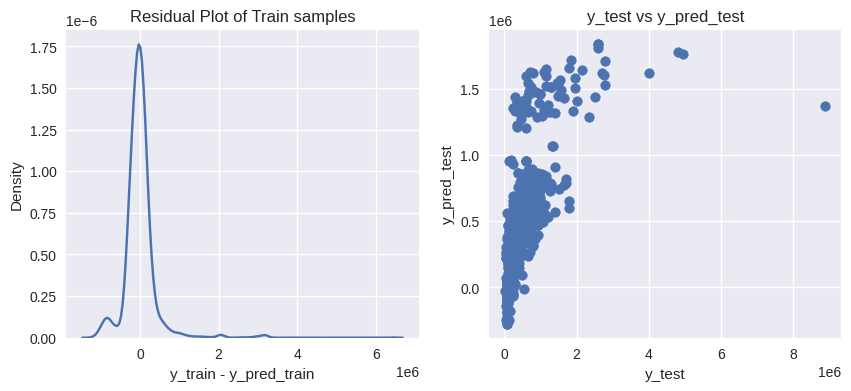

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Prepare the data
X = df_main.drop(['name', 'selling_price'], axis=1)
y = df_main['selling_price']

# One-hot encode categorical features
X = pd.get_dummies(X, columns=['fuel', 'seller_type', 'transmission', 'owner'], drop_first=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
car_pred_model(lr,"Linear_regressor.pkl")

Train R2-score : 0.47
Test R2-score : 0.4
Train CV scores : [0.50241144 0.45825292 0.48703693 0.46439399 0.42712274]
Train CV mean : 0.47


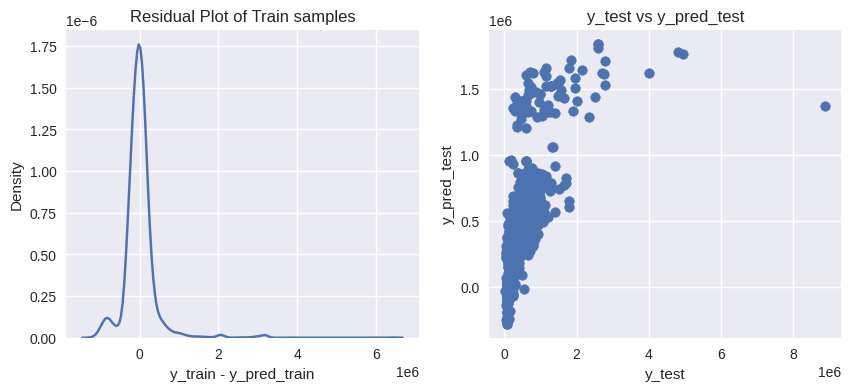

In [42]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV

# Creating Ridge model object
rg = Ridge()
# range of alpha
alpha = np.logspace(-3,3,num=14)

# Creating RandomizedSearchCV to find the best estimator of hyperparameter
rg_rs = RandomizedSearchCV(estimator = rg, param_distributions = dict(alpha=alpha))

car_pred_model(rg_rs,"ridge.pkl")

In [43]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import RandomizedSearchCV

ls = Lasso()
alpha = np.logspace(-3,3,num=14) # range for alpha

ls_rs = RandomizedSearchCV(estimator = ls, param_distributions = dict(alpha=alpha))

Train R2-score : 0.47
Test R2-score : 0.4
Train CV scores : [0.50279748 0.45778096 0.48794441 0.46388542 0.42639643]
Train CV mean : 0.47


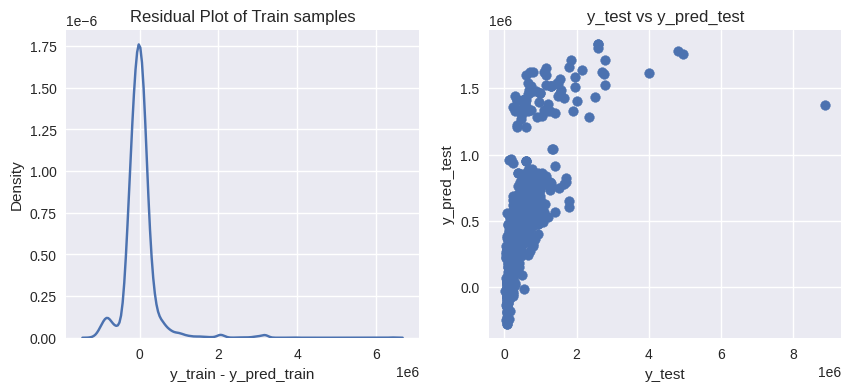

In [44]:
car_pred_model(ls_rs,"lasso.pkl")

In [45]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor()

# Number of trees in Random forest
n_estimators=list(range(500,1000,100))
# Maximum number of levels in a tree
max_depth=list(range(4,9,4))
# Minimum number of samples required to split an internal node
min_samples_split=list(range(4,9,2))
# Minimum number of samples required to be at a leaf node.
min_samples_leaf=[1,2,5,7]
# Number of fearures to be considered at each split
max_features=['auto','sqrt']

# Hyperparameters dict
param_grid = {"n_estimators":n_estimators,
              "max_depth":max_depth,
              "min_samples_split":min_samples_split,
              "min_samples_leaf":min_samples_leaf,
              "max_features":max_features}

rf_rs = RandomizedSearchCV(estimator = rf, param_distributions = param_grid)

Train R2-score : 0.69
Test R2-score : 0.52
Train CV scores : [0.71365918 0.60892529 0.56222698 0.76113959 0.63953942]
Train CV mean : 0.66


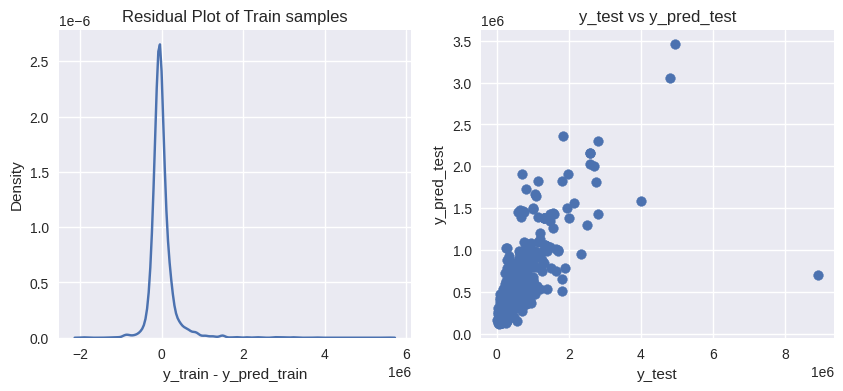

In [46]:
car_pred_model(rf_rs,'random_forest.pkl')


In [47]:
print(rf_rs.best_estimator_)

RandomForestRegressor(max_depth=8, max_features='sqrt', min_samples_leaf=5,
                      min_samples_split=6, n_estimators=900)


In [48]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

gb = GradientBoostingRegressor()

# Rate at which correcting is being made
learning_rate = [0.001, 0.01, 0.1, 0.2]
# Number of trees in Gradient boosting
n_estimators=list(range(500,1000,100))
# Maximum number of levels in a tree
max_depth=list(range(4,9,4))
# Minimum number of samples required to split an internal node
min_samples_split=list(range(4,9,2))
# Minimum number of samples required to be at a leaf node.
min_samples_leaf=[1,2,5,7]
# Number of fearures to be considered at each split
max_features=['auto','sqrt']

# Hyperparameters dict
param_grid = {"learning_rate":learning_rate,
              "n_estimators":n_estimators,
              "max_depth":max_depth,
              "min_samples_split":min_samples_split,
              "min_samples_leaf":min_samples_leaf,
              "max_features":max_features}

gb_rs = RandomizedSearchCV(estimator = gb, param_distributions = param_grid)

Train R2-score : 0.73
Test R2-score : 0.52
Train CV scores : [0.66158909 0.66004517 0.55349954 0.75255595 0.65750219]
Train CV mean : 0.66


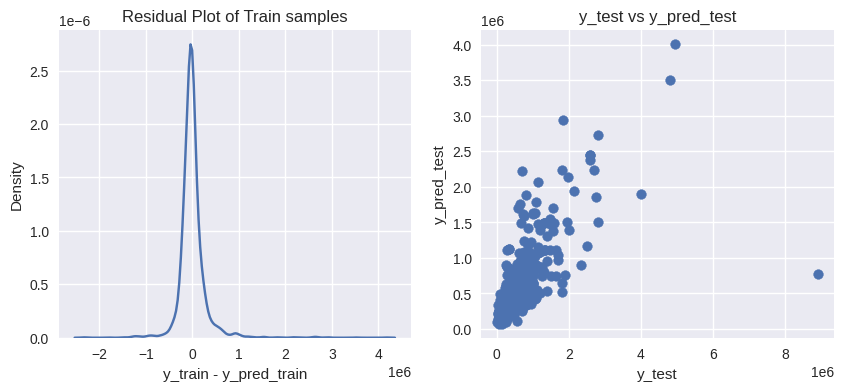

In [49]:
car_pred_model(gb_rs,"gradient_boosting.pkl")

In [51]:
from IPython.display import display

Technique = ["LinearRegression","Ridge","Lasso","RandomForestRegressor","GradientBoostingRegressor"]
results=pd.DataFrame({'Model': Technique,'R Squared(Train)': R2_train,'R Squared(Test)': R2_test,'CV score mean(Train)': CV})
display(results)

,Model,R Squared(Train),R Squared(Test),CV score mean(Train)
0,LinearRegression,0.47,0.40,0.47
1,Ridge,0.47,0.40,0.47
2,Lasso,0.47,0.40,0.47
3,RandomForestRegressor,0.69,0.52,0.66
4,GradientBoostingRegressor,0.73,0.52,0.66
